In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("saurav9786/amazon-product-reviews")

print("Dataset downloaded to:", path)
print(os.listdir(path))

100%|██████████| 109M/109M [00:00<00:00, 202MB/s] 

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/saurav9786/amazon-product-reviews/versions/1
['ratings_Electronics (1).csv']


In [3]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/saurav9786/amazon-product-reviews/versions/1/ratings_Electronics (1).csv


In [4]:
import pandas as pd

file_path = "/root/.cache/kagglehub/datasets/saurav9786/amazon-product-reviews/versions/1/ratings_Electronics (1).csv"

df_sample = pd.read_csv(
    file_path,
    header=None,
    nrows=10
)

print(df_sample)
print("\nShape of sample:", df_sample.shape)

                0          1    2           3
0   AKM1MP6P0OYPR  132793040  5.0  1365811200
1  A2CX7LUOHB2NDG  321732944  5.0  1341100800
2  A2NWSAGRHCP8N5  439886341  1.0  1367193600
3  A2WNBOD3WNDNKT  439886341  3.0  1374451200
4  A1GI0U4ZRJA8WN  439886341  1.0  1334707200
5  A1QGNMC6O1VW39  511189877  5.0  1397433600
6  A3J3BRHTDRFJ2G  511189877  2.0  1397433600
7  A2TY0BTJOTENPG  511189877  5.0  1395878400
8  A34ATBPOK6HCHY  511189877  5.0  1395532800
9   A89DO69P0XZ27  511189877  5.0  1395446400

Shape of sample: (10, 4)


In [5]:
import pandas as pd

# Column names according to the dataset
columns = ["user_id", "item_id", "rating", "timestamp"]

# Statistics we need
total_rows = 0
rating_counts = {}

unique_users = set()
unique_items = set()
unique_timestamps = set()

# Process the CSV in chunks
for chunk in pd.read_csv(
    file_path,
    header=None,
    names=columns,
    chunksize=100000
):
    total_rows += len(chunk)

    # Count ratings
    counts = chunk["rating"].value_counts()
    for rating, count in counts.items():
        rating_counts[rating] = rating_counts.get(rating, 0) + count

    # Unique values
    unique_users.update(chunk["user_id"].unique())
    unique_items.update(chunk["item_id"].unique())
    unique_timestamps.update(chunk["timestamp"].unique())

print("Total number of rows:", total_rows)

print("\nRating distribution:")
for rating in sorted(rating_counts):
    print(f"{rating} stars: {rating_counts[rating]}")

print("\nNumber of unique users:", len(unique_users))
print("Number of unique products:", len(unique_items))
print("Number of unique timestamps:", len(unique_timestamps))

Total number of rows: 7824482

Rating distribution:
1.0 stars: 901765
2.0 stars: 456322
3.0 stars: 633073
4.0 stars: 1485781
5.0 stars: 4347541

Number of unique users: 4201696
Number of unique products: 476002
Number of unique timestamps: 5489


In [6]:
import pandas as pd
from collections import Counter

columns = ["user_id", "item_id", "rating", "timestamp"]

user_counts = Counter()
item_counts = Counter()

for chunk in pd.read_csv(
    file_path,
    header=None,
    names=columns,
    chunksize=100000
):
    user_counts.update(chunk["user_id"])
    item_counts.update(chunk["item_id"])

valid_users = {user for user, count in user_counts.items() if count >= 5}
valid_items = {item for item, count in item_counts.items() if count >= 5}

print("Users with at least 5 ratings:", len(valid_users))
print("Products with at least 5 ratings:", len(valid_items))

Users with at least 5 ratings: 254064
Products with at least 5 ratings: 157783


In [7]:
import os

clean_file = "/content/ratings_clean.csv"

# Remove previous file if it exists
if os.path.exists(clean_file):
    os.remove(clean_file)

first_chunk = True
clean_rows = 0

for chunk in pd.read_csv(
    file_path,
    header=None,
    names=columns,
    chunksize=100000
):
    # Keep only users and products with at least 5 ratings
    filtered = chunk[
        chunk["user_id"].isin(valid_users) &
        chunk["item_id"].isin(valid_items)
    ]

    if len(filtered) > 0:
        filtered.to_csv(
            clean_file,
            mode="w" if first_chunk else "a",
            header=first_chunk,
            index=False
        )

        first_chunk = False
        clean_rows += len(filtered)

print("Clean dataset created!")
print("Rows in cleaned dataset:", clean_rows)
print("Saved to:", clean_file)

Clean dataset created!
Rows in cleaned dataset: 2109869
Saved to: /content/ratings_clean.csv


In [8]:
import pandas as pd

sample_file = "/content/ratings_sample.csv"

sample_df = pd.read_csv(
    clean_file
).sample(
    n=50000,
    random_state=42
)

sample_df.to_csv(sample_file, index=False)

print("Sample created!")
print("Rows:", len(sample_df))
print("Saved to:", sample_file)

print("\nFirst 5 rows:")
print(sample_df.head())

Sample created!
Rows: 50000
Saved to: /content/ratings_sample.csv

First 5 rows:
                user_id     item_id  rating   timestamp
865300   A1PLZRS9YGDOSU  B0030CHI14     5.0  1319328000
1973175   AVCSVBOZJBC4L  B00CA66YGQ     4.0  1393372800
414359   A14RFF9JUIM34U  B000V7AF8E     4.0  1366934400
535531   A2F9SYJEBT2YBV  B001AHTEEU     5.0  1376179200
1048708  A13DAQHQXMBVKA  B003WTNGW0     4.0  1341964800


In [9]:
print("Clean dataset:")
print(pd.read_csv(clean_file, nrows=5))

print("\nSample dataset:")
print(pd.read_csv(sample_file, nrows=5))

Clean dataset:
          user_id    item_id  rating   timestamp
0  A3J3BRHTDRFJ2G  511189877     2.0  1397433600
1   AZYNQZ94U6VDB  511189877     5.0  1401321600
2   AO94DHGC771SJ  528881469     5.0  1370131200
3   AMO214LNFCEI4  528881469     1.0  1290643200
4  A3N7T0DY83Y4IG  528881469     3.0  1283990400

Sample dataset:
          user_id     item_id  rating   timestamp
0  A1PLZRS9YGDOSU  B0030CHI14     5.0  1319328000
1   AVCSVBOZJBC4L  B00CA66YGQ     4.0  1393372800
2  A14RFF9JUIM34U  B000V7AF8E     4.0  1366934400
3  A2F9SYJEBT2YBV  B001AHTEEU     5.0  1376179200
4  A13DAQHQXMBVKA  B003WTNGW0     4.0  1341964800


In [10]:
import pandas as pd
import numpy as np

# Load cleaned data
df = pd.read_csv(clean_file)

# Give every rating a unique ID
df.insert(0, "review_id", range(len(df)))

# Shuffle indices using fixed seed
rng = np.random.default_rng(42)
shuffled_indices = rng.permutation(len(df))

# Calculate split sizes
n = len(df)
train_end = int(0.80 * n)
val_end = int(0.90 * n)

# Create split labels
split = np.empty(n, dtype=object)

split[shuffled_indices[:train_end]] = "train"
split[shuffled_indices[train_end:val_end]] = "validation"
split[shuffled_indices[val_end:]] = "test"

# Create split file
split_df = pd.DataFrame({
    "review_id": df["review_id"],
    "split": split
})

split_file = "/content/split.csv"
split_df.to_csv(split_file, index=False)

print("Split created!")
print("Total:", len(split_df))
print("\nSplit distribution:")
print(split_df["split"].value_counts())
print("\nSaved to:", split_file)

Split created!
Total: 2109869

Split distribution:
split
train         1687895
test           210987
validation     210987
Name: count, dtype: int64

Saved to: /content/split.csv


In [11]:
print(split_df.head(10))
print("\nSplit percentages:")
print(split_df["split"].value_counts(normalize=True) * 100)

   review_id  split
0          0  train
1          1  train
2          2  train
3          3  train
4          4   test
5          5  train
6          6  train
7          7  train
8          8  train
9          9  train

Split percentages:
split
train         79.999991
test          10.000005
validation    10.000005
Name: proportion, dtype: float64


In [12]:
# Count ratings per product
item_counts = df["item_id"].value_counts()

# Products having between 50 and 200 ratings
candidate_items = item_counts[
    (item_counts >= 50) & (item_counts <= 200)
]

print("Number of candidate products:", len(candidate_items))

# Choose the product with the highest number of ratings
target_item = candidate_items.index[0]

print("Selected target product:", target_item)
print("Existing ratings:", item_counts[target_item])

Number of candidate products: 6296
Selected target product: B0045DMA42
Existing ratings: 200


In [13]:
target_data = df[df["item_id"] == target_item]

target_average = target_data["rating"].mean()

print("Target product:", target_item)
print("Number of existing ratings:", len(target_data))
print("Current average rating:", round(target_average, 3))
print("\nRating distribution:")
print(target_data["rating"].value_counts().sort_index())

Target product: B0045DMA42
Number of existing ratings: 200
Current average rating: 3.39

Rating distribution:
rating
1.0    35
2.0    26
3.0    38
4.0    28
5.0    73
Name: count, dtype: int64


In [14]:
import pandas as pd
import numpy as np

# Reproducible random generator
rng = np.random.default_rng(42)

# Target product
target_item = target_item

# Number of fake users
num_fake_users = 50

# Number of other products each fake user rates
num_other_items = 20

# Existing target average
target_average = target_data["rating"].mean()

# All available products except target
other_items = df.loc[
    df["item_id"] != target_item,
    "item_id"
].unique()

fake_rows = []

# Generate 50 fake users
for i in range(num_fake_users):

    fake_user_id = f"FAKE_USER_{i+1:03d}"

    # Select 20 different products
    selected_items = rng.choice(
        other_items,
        size=num_other_items,
        replace=False
    )

    # Ratings near target average (3.29)
    # 3 or 4 stars, centered around the target average
    other_ratings = rng.choice(
        [3.0, 4.0],
        size=num_other_items,
        p=[0.71, 0.29]
    )

    # Target product: always 5 stars
    fake_rows.append({
        "user_id": fake_user_id,
        "item_id": target_item,
        "rating": 5.0,
        "timestamp": int(rng.choice(df["timestamp"].values)),
        "is_fake": True
    })

    # 20 normal-looking ratings
    for item, rating in zip(selected_items, other_ratings):
        fake_rows.append({
            "user_id": fake_user_id,
            "item_id": item,
            "rating": rating,
            "timestamp": int(rng.choice(df["timestamp"].values)),
            "is_fake": True
        })

fake_df = pd.DataFrame(fake_rows)

print("Fake users:", fake_df["user_id"].nunique())
print("Fake ratings:", len(fake_df))

print("\nRatings on target product:")
print(
    fake_df[fake_df["item_id"] == target_item]["rating"].value_counts()
)

print("\nFake data preview:")
print(fake_df.head(10))

Fake users: 50
Fake ratings: 1050

Ratings on target product:
rating
5.0    50
Name: count, dtype: int64

Fake data preview:
         user_id     item_id  rating   timestamp  is_fake
0  FAKE_USER_001  B0045DMA42     5.0  1377820800     True
1  FAKE_USER_001  B0085E4WQQ     4.0  1391731200     True
2  FAKE_USER_001  B0072LAAM8     3.0  1297296000     True
3  FAKE_USER_001  B000SIAFCM     4.0  1218499200     True
4  FAKE_USER_001  B00GMGDFPI     4.0  1380585600     True
5  FAKE_USER_001  B009OUFP1Q     4.0  1334188800     True
6  FAKE_USER_001  B007YJIGPQ     3.0  1367366400     True
7  FAKE_USER_001  B000E31PNY     3.0  1397260800     True
8  FAKE_USER_001  B0006JI3KE     3.0  1404518400     True
9  FAKE_USER_001  B005JK63RA     3.0  1387324800     True


In [15]:
# Mark all original ratings as genuine
original_df = df.copy()
original_df["is_fake"] = False

# Give fake rows new review IDs
start_id = original_df["review_id"].max() + 1

fake_df.insert(
    0,
    "review_id",
    range(start_id, start_id + len(fake_df))
)

# Make sure column order matches
fake_df = fake_df[
    ["review_id", "user_id", "item_id", "rating", "timestamp", "is_fake"]
]

original_df = original_df[
    ["review_id", "user_id", "item_id", "rating", "timestamp", "is_fake"]
]

# Combine
attacked_df = pd.concat(
    [original_df, fake_df],
    ignore_index=True
)

attacked_file = "/content/attacked_ratings.csv"

attacked_df.to_csv(
    attacked_file,
    index=False
)

print("Attacked dataset created!")
print("Original ratings:", len(original_df))
print("Fake ratings:", len(fake_df))
print("Total ratings:", len(attacked_df))
print("Saved to:", attacked_file)

Attacked dataset created!
Original ratings: 2109869
Fake ratings: 1050
Total ratings: 2110919
Saved to: /content/attacked_ratings.csv


In [16]:
print("Fake/Genuine counts:")
print(attacked_df["is_fake"].value_counts())

print("\nFake users:")
print(
    attacked_df[attacked_df["is_fake"] == True]["user_id"].nunique()
)

print("\nTarget product ratings:")
print(
    attacked_df[
        attacked_df["item_id"] == target_item
    ]["rating"].value_counts().sort_index()
)

Fake/Genuine counts:
is_fake
False    2109869
True        1050
Name: count, dtype: int64

Fake users:
50

Target product ratings:
rating
1.0     35
2.0     26
3.0     38
4.0     28
5.0    123
Name: count, dtype: int64


In [17]:
# Average rating before attack
before_average = df[
    df["item_id"] == target_item
]["rating"].mean()

# Average rating after attack
after_average = attacked_df[
    attacked_df["item_id"] == target_item
]["rating"].mean()

# Change
change = after_average - before_average

print("Target Product:", target_item)
print("--------------------------------")
print("Average BEFORE attack:", round(before_average, 4))
print("Average AFTER attack: ", round(after_average, 4))
print("Change in rating:     ", round(change, 4))

Target Product: B0045DMA42
--------------------------------
Average BEFORE attack: 3.39
Average AFTER attack:  3.712
Change in rating:      0.322


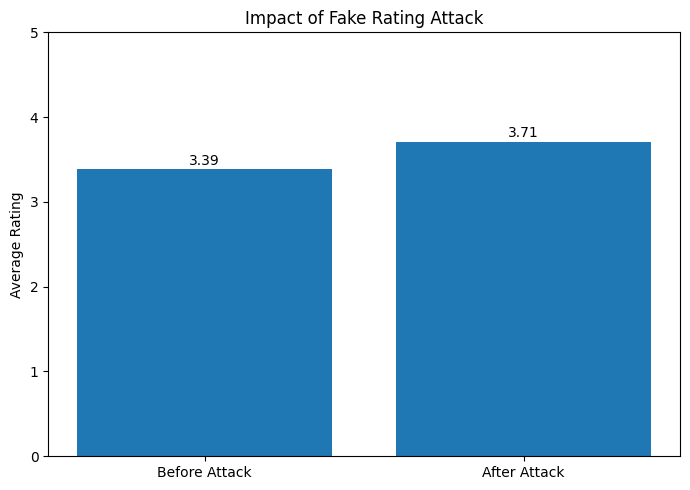

In [18]:
import matplotlib.pyplot as plt

labels = ["Before Attack", "After Attack"]
values = [before_average, after_average]

plt.figure(figsize=(7, 5))

plt.bar(labels, values)

plt.ylabel("Average Rating")
plt.title("Impact of Fake Rating Attack")

# Show values above bars
for i, value in enumerate(values):
    plt.text(
        i,
        value + 0.05,
        f"{value:.2f}",
        ha="center"
    )

plt.ylim(0, 5)
plt.tight_layout()

plt.savefig(
    "/content/attack_impact.png",
    dpi=300
)

plt.show()

In [19]:
original_target_count = len(
    df[df["item_id"] == target_item]
)

fake_target_count = len(
    fake_df[fake_df["item_id"] == target_item]
)

total_target_count = len(
    attacked_df[attacked_df["item_id"] == target_item]
)

print("Original target ratings:", original_target_count)
print("Fake target ratings:", fake_target_count)
print("Total target ratings:", total_target_count)

print(
    "\nFake rating percentage:",
    round(
        (fake_target_count / total_target_count) * 100,
        2
    ),
    "%"
)

Original target ratings: 200
Fake target ratings: 50
Total target ratings: 250

Fake rating percentage: 20.0 %


In [20]:
import numpy as np
import pandas as pd


def calculate_rmse(actual, predicted):
    """
    Calculate Root Mean Squared Error (RMSE).
    """
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    if len(actual) != len(predicted):
        raise ValueError("Actual and predicted values must have the same length.")

    return np.sqrt(np.mean((actual - predicted) ** 2))


def calculate_target_score_change(before_score, after_score):
    """
    Calculate how much the target product's score changed.
    """
    return after_score - before_score


def evaluate_predictions(actual, predicted,
                         target_before=None,
                         target_after=None):
    """
    Return RMSE and, optionally, target score change.
    """

    rmse = calculate_rmse(actual, predicted)

    result = {
        "rmse": rmse
    }

    if target_before is not None and target_after is not None:
        result["target_score_change"] = (
            calculate_target_score_change(
                target_before,
                target_after
            )
        )

    return result

In [21]:
actual = [4, 5, 3, 2, 4]
predicted = [4.2, 4.8, 3.1, 2.3, 3.9]

result = evaluate_predictions(
    actual,
    predicted,
    target_before=3.39,
    target_after=3.712
)

print("RMSE:", round(result["rmse"], 4))
print(
    "Target score change:",
    round(result["target_score_change"], 4)
)

RMSE: 0.1949
Target score change: 0.322


In [22]:
def trust_adjusted_rating(
    data,
    item_id,
    fake_weight=0.1
):
    """
    Calculate a weighted average rating.

    Genuine ratings receive weight 1.0.
    Ratings marked as fake receive a lower weight.
    """

    item_data = data[data["item_id"] == item_id].copy()

    if len(item_data) == 0:
        raise ValueError("Item not found.")

    weights = np.where(
        item_data["is_fake"],
        fake_weight,
        1.0
    )

    weighted_average = np.average(
        item_data["rating"],
        weights=weights
    )

    return weighted_average

In [23]:
normal_rating = attacked_df[
    attacked_df["item_id"] == target_item
]["rating"].mean()

trust_rating = trust_adjusted_rating(
    attacked_df,
    target_item,
    fake_weight=0.1
)

print("Target product:", target_item)
print("Normal average:", round(normal_rating, 3))
print("Trust-adjusted average:", round(trust_rating, 3))

Target product: B0045DMA42
Normal average: 3.712
Trust-adjusted average: 3.429


In [24]:
import os
import shutil

project_dir = "/content/data_and_attacks"

# Create project folder
os.makedirs(project_dir, exist_ok=True)

# Copy the generated files
files_to_copy = [
    "/content/ratings_sample.csv",
    "/content/ratings_clean.csv",
    "/content/split.csv",
    "/content/attacked_ratings.csv",
    "/content/attack_impact.png"
]

for file_path in files_to_copy:
    if os.path.exists(file_path):
        shutil.copy2(
            file_path,
            os.path.join(project_dir, os.path.basename(file_path))
        )

print("Project folder created:")
print(project_dir)

print("\nFiles:")
for file in os.listdir(project_dir):
    print("-", file)

Project folder created:
/content/data_and_attacks

Files:
- attacked_ratings.csv
- split.csv
- ratings_clean.csv
- attack_impact.png
- ratings_sample.csv


In [25]:
scoring_code = '''
import numpy as np


def calculate_rmse(actual, predicted):
    """
    Calculate Root Mean Squared Error (RMSE).
    """
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    if len(actual) != len(predicted):
        raise ValueError(
            "Actual and predicted values must have the same length."
        )

    return np.sqrt(np.mean((actual - predicted) ** 2))


def calculate_target_score_change(before_score, after_score):
    """
    Calculate the change in a target product's score.
    """
    return after_score - before_score


def evaluate_predictions(
    actual,
    predicted,
    target_before=None,
    target_after=None
):
    """
    Calculate RMSE and optionally target score change.
    """

    rmse = calculate_rmse(actual, predicted)

    result = {
        "rmse": rmse
    }

    if target_before is not None and target_after is not None:
        result["target_score_change"] = (
            calculate_target_score_change(
                target_before,
                target_after
            )
        )

    return result
'''

with open(
    os.path.join(project_dir, "scoring.py"),
    "w"
) as f:
    f.write(scoring_code)

print("scoring.py created.")

scoring.py created.


In [26]:
requirements = """pandas
numpy
matplotlib
"""

with open(
    os.path.join(project_dir, "requirements.txt"),
    "w"
) as f:
    f.write(requirements)

print("requirements.txt created.")

requirements.txt created.


In [27]:
readme = f"""# Recommendation Pipeline - Fake Rating Attack

## Overview

This module prepares Amazon product rating data and simulates a fake-rating
attack against a recommendation pipeline.

The workflow is:

1. Explore the ratings dataset.
2. Filter users with at least 5 ratings.
3. Filter products with at least 5 ratings.
4. Create a 50,000-row sample.
5. Create an 80/10/10 train-validation-test split.
6. Generate fake users and fake ratings.
7. Measure the effect of the attack on a target product.
8. Provide scoring utilities for RMSE and target-score change.

## Dataset Statistics

Original dataset:

- Total ratings: 7,824,482
- Unique users: 4,201,696
- Unique products: 476,002
- Unique timestamps: 5,489

Rating distribution:

- 1 star: 901,765
- 2 stars: 456,322
- 3 stars: 633,073
- 4 stars: 1,485,781
- 5 stars: 4,347,541

## Cleaned Dataset

Filtering criteria:

- Users with at least 5 ratings
- Products with at least 5 ratings

Results:

- Users satisfying minimum rating requirement: 254,064
- Products satisfying minimum rating requirement: 157,783
- Cleaned ratings: 2,109,869

## Train / Validation / Test Split

The cleaned dataset is split using random seed 42:

- Training: 80%
- Validation: 10%
- Test: 10%

Files:

- `ratings_sample.csv`
- `ratings_clean.csv`
- `split.csv`

## Fake Rating Attack

Target product:

`{target_item}`

Original target ratings:

- 200

Fake users:

- 50

Each fake user:

- Gives the target product a 5-star rating.
- Rates 20 additional products with ratings near the target product's average.

Total fake ratings:

- 1,050

Fake ratings added to target product:

- 50

Percentage of target-product ratings that are fake after attack:

- 20%

## Attack Results

Target product average before attack:

- {before_average:.3f}

Target product average after attack:

- {after_average:.3f}

Change:

- {change:.3f}

The chart showing this effect is stored in:

`attack_impact.png`

## Scoring

`scoring.py` provides:

- RMSE calculation
- Target score change calculation
- Combined prediction evaluation

## Important

The fake-review detector and SVD/ALS recommendation models are not implemented here.
This module produces the prepared data and simulated attack required by those
components.

## Files

- `ratings_sample.csv` - approximately 50,000 cleaned ratings
- `ratings_clean.csv` - filtered ratings dataset
- `split.csv` - train/validation/test assignment
- `attacked_ratings.csv` - cleaned data plus simulated fake ratings
- `attack_impact.png` - before/after attack visualization
- `scoring.py` - evaluation functions
- `requirements.txt` - Python dependencies
"""

with open(
    os.path.join(project_dir, "README.md"),
    "w"
) as f:
    f.write(readme)

print("README.md created.")

README.md created.


In [28]:
print("FINAL PROJECT STRUCTURE")
print("=" * 40)

for root, dirs, files in os.walk(project_dir):
    level = root.replace(project_dir, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        file_path = os.path.join(root, file)
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"{indent}    {file} ({size_mb:.2f} MB)")

FINAL PROJECT STRUCTURE
data_and_attacks/
    attacked_ratings.csv (109.13 MB)
    split.csv (27.92 MB)
    ratings_clean.csv (81.97 MB)
    attack_impact.png (0.06 MB)
    README.md (0.00 MB)
    ratings_sample.csv (1.94 MB)
    requirements.txt (0.00 MB)
    scoring.py (0.00 MB)


In [29]:
attack_generator_code = '''
import pandas as pd
import numpy as np


def generate_attack(df, target_item, num_fake_users=50,
                    num_other_items=20, seed=42):

    rng = np.random.default_rng(seed)

    target_data = df[df["item_id"] == target_item]

    if len(target_data) == 0:
        raise ValueError("Target item not found.")

    target_average = target_data["rating"].mean()

    other_items = df.loc[
        df["item_id"] != target_item,
        "item_id"
    ].unique()

    fake_rows = []

    for i in range(num_fake_users):

        fake_user_id = f"FAKE_USER_{i+1:03d}"

        selected_items = rng.choice(
            other_items,
            size=num_other_items,
            replace=False
        )

        other_ratings = rng.choice(
            [3.0, 4.0],
            size=num_other_items,
            p=[0.71, 0.29]
        )

        fake_rows.append({
            "user_id": fake_user_id,
            "item_id": target_item,
            "rating": 5.0,
            "timestamp": int(rng.choice(df["timestamp"].values)),
            "is_fake": True
        })

        for item, rating in zip(selected_items, other_ratings):

            fake_rows.append({
                "user_id": fake_user_id,
                "item_id": item,
                "rating": rating,
                "timestamp": int(rng.choice(df["timestamp"].values)),
                "is_fake": True
            })

    fake_df = pd.DataFrame(fake_rows)

    original_df = df.copy()
    original_df["is_fake"] = False

    start_id = original_df["review_id"].max() + 1

    fake_df.insert(
        0,
        "review_id",
        range(start_id, start_id + len(fake_df))
    )

    columns = [
        "review_id",
        "user_id",
        "item_id",
        "rating",
        "timestamp",
        "is_fake"
    ]

    original_df = original_df[columns]
    fake_df = fake_df[columns]

    attacked_df = pd.concat(
        [original_df, fake_df],
        ignore_index=True
    )

    return attacked_df
'''

with open(
    "/content/data_and_attacks/attack_generator.py",
    "w"
) as f:
    f.write(attack_generator_code)

print("attack_generator.py created successfully.")

attack_generator.py created successfully.


In [30]:
import shutil

zip_path = shutil.make_archive(
    "/content/data_and_attacks",
    "zip",
    "/content/data_and_attacks"
)

print("Created:", zip_path)

Created: /content/data_and_attacks.zip


In [31]:
from google.colab import files

files.download("/content/data_and_attacks.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>